АВТ-213 Гомзякова Софья

# Лабораторная работа: Спайковые нейронные сети

# Теоретическая часть

## 1. Суть нейроморфных вычислений и спайковых нейронных сетей

Нейроморфные вычисления — это парадигма, направленная на создание вычислительных систем, архитектура и принципы работы которых вдохновлены биологическим мозгом. В отличие от классических нейронных сетей, которые оперируют непрерывными значениями активаций (например, вещественными числами), спайковые нейронные сети (Spiking Neural Networks, SNN) используют **дискретные события во времени** — спайки (или потенциалы действия).

Основная цель нейроморфных систем — достичь высокой **энергоэффективности** и способности эффективно обрабатывать **временно́зависимые данные** (аудио, видео, сенсорные потоки), что критически важно для задач встраиваемого ИИ, робототехники и интерфейсов мозг-компьютер.


## 2. Модель нейрона LIF (Leaky Integrate-and-Fire)

Модель LIF является одной из самых распространенных и вычислительно эффективных моделей спайкового нейрона. Она описывает динамику мембранного потенциала $V(t)$.

Уравнение мембранного потенциала:

$$
\tau_m \frac{dV(t)}{dt} = -(V(t) - V_{rest}) + R_m I(t)
$$

где:
- $V(t)$ — мембранный потенциал в момент времени $t$,
- $\tau_m = R_m C_m$ — постоянная времени мембраны (произведение сопротивления $R_m$ и емкости $C_m$),
- $V_{rest}$ — потенциал покоя,
- $R_m$ — мембранное сопротивление,
- $I(t)$ — суммарный входной ток (от синапсов).

При достижении порогового потенциала $V_{th}$ нейрон генерирует спайк, и его потенциал сбрасывается до потенциала покоя $V_{rest}$ на период рефрактерности $\tau_{ref}$:

$$
\text{if } V(t) \geq V_{th} \text{, then:} \\
V(t) \rightarrow V_{rest} \\
\text{Запрет на срабатывание на время } \tau_{ref}
$$

## 3. Спайк-тайм-зависимая пластичность (STDP)

STDP — это биоинспирированное правило обучения, которое модифицирует силу синаптической связи (вес $w$) на основе временной корреляции между спайками пресинаптического и постсинаптического нейронов.

Формально, изменение веса $\Delta w$ определяется так:

$$
\Delta w =
\begin{cases}
A_{+} \cdot \exp\left(-\frac{\Delta t}{\tau_{+}}\right), & \text{если } \Delta t > 0 \text{ (пре-спайк до пост-спайка)} \\
-A_{-} \cdot \exp\left(-\frac{|\Delta t|}{\tau_{-}}\right), & \text{если } \Delta t < 0 \text{ (пре-спайк после пост-спайка)}
\end{cases}
$$

где:
- $\Delta t = t_{post} - t_{pre}$ — разница во времени между постсинаптическим и пресинаптическим спайками,
- $A_{+}, A_{-}$ — амплитуды усиления и ослабления связи,
- $\tau_{+}, \tau_{-}$ — временные константы для потенциации и депрессии.

STDP реализует принцип Хебба: *"Neurons that fire together, wire together"* (Нейроны, которые возбуждаются вместе, связываются вместе).

## Практическая часть

В данной работе вам предлагается реализовать и исследовать простую спайковую нейронную сеть на основе модели LIF с обучением по правилу STDP. Вы должны:

1.  Реализовать модель LIF-нейрона и исследовать его отклик на различные входные токи.
2.  Создать сеть из нескольких LIF-нейронов (например, входной слой, скрытый слой) и визуализировать распространение спайковой активности.
3.  Реализовать правило обучения STDP для синаптических связей.
4.  Обучить сеть на простой задаче (например, ассоциации паттернов) или классификации простых спайковых последовательностей.
5.  Проанализировать динамику весов, итоговую активность сети и эффективность обучения.

### Импорты

In [226]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from scipy.optimize import linear_sum_assignment

Случайное зерно для воспроизводимости:

In [227]:
np.random.seed(42)

Класс для Leaky Integrate-and-Fire нейрона. Нейрон получает входящий сигнал I_inj, что повышает его мембранный потенциал по Эйлеровой схеме. В случае возникновения спайка (превышения порогового потенциала) потенциал сбрасывается до потенциала сброса, а время спайка записывается в массив. После спайка нейрон не может сгенерировать новый спайк в течение $ \tau_{ref} $ мс.

In [228]:
# Определение параметров нейрона LIF
@dataclass
class LIFNeuron:
    tau_m: float = 20.0    # Постоянная времени мембраны (мс)
    v_rest: float = -70.0  # Потенциал покоя (мВ)
    v_thresh: float = -55.0 # Пороговый потенциал (мВ)
    v_reset: float = -75.0 # Потенциал сброса (мВ)
    r_m: float = 10.0      # Мембранное сопротивление (МОм)
    tau_ref: float = 4.0   # Рефрактерный период (мс)

    def __post_init__(self):
        self.v = self.v_rest
        self.refractory_until = 0
        self.spike_times = []
        self.spike = False
        self.v_trace = []

    def step(self, I_inj: float, dt: float, t: float) -> bool:
        """Один шаг интегрирования. Возвращает True, если был спайк."""
        self.spike = False
        # Проверка рефрактерности
        if t < self.refractory_until:
            self.v = self.v_reset

            self.v_trace.append(self.v)

            return False

        # Интегрирование уравнения LIF (простая Эйлерова схема)
        dv = (-(self.v - self.v_rest) + self.r_m * I_inj) / self.tau_m
        self.v += dv * dt

        # Проверка на срабатывание
        if self.v >= self.v_thresh:
            self.v = self.v_reset
            self.refractory_until = t + self.tau_ref
            self.spike_times.append(t)

            # self.v_trace.append(self.v)
            self.spike = True
            # return True
        
        self.v_trace.append(self.v)
        return self.spike

Модель спайковой нейронной сети на основе STDP. Сеть состоит из двух полносвязных слоев. Синаптические связи слоев имеют веса, управляемые принципом STDP.

Метод init_weights возвращает начальные веса с заданным распределением:
- set=True: веса связей равны A
- set=False, normal=False: веса связей задаются равномерным распределением в полуинтервале [0, A]
- set=False, normal=True: веса связей задаются нормальным распределением с заданными $ \mu $ и $ \sigma $

Сигнал по синапсу передается только в том случае, если входной нейрон породил спайк.

In [229]:
class SNNNetwork:
    def init_weights(n_inputs, n_outputs, set=True, normal=False, A=1.0, mu=0.0, sigma=1):
        if set:
            weights = [[A for j in range(n_outputs)] for i in range(n_inputs)]
        elif normal:
            weights = [[np.random.normal(loc=mu, scale=sigma) for j in range(n_outputs)] for i in range(n_inputs)]
        else:
            weights = [[np.random.random() * A for j in range(n_outputs)] for i in range(n_inputs)]
        return weights
    
    def __init__(self, n_inputs, n_outputs, t_range, I_inj, weights, dt=0.1, A_p=1, A_m=1, tau_p=1, tau_m=1):
        # связей: n_inputs * n_outputs
        self.n_inputs = n_inputs
        self.n_outputs = n_outputs

        self.dt = dt
        self.t_range = t_range
        self.I_inj = I_inj  # t_range * n_inputs
        self.weights = weights
        self.weight_history = [[[] for j in range(n_outputs)] for i in range(n_inputs)]
        self.A_p = A_p
        self.A_m = A_m
        self.tau_p = tau_p
        self.tau_m = tau_m
        self.inputs = [LIFNeuron() for i in range(n_inputs)]
        self.outputs = [LIFNeuron() for j in range(n_outputs)]

    def _update_weights(self, t):
        for i, input in enumerate(self.inputs):
            for j, output in enumerate(self.outputs):
                last_spike_in = input.spike_times[-1] if len(input.spike_times) else -float('inf')
                last_spike_out = output.spike_times[-1] if len(output.spike_times) else -float('inf')
                spike_dif = last_spike_out - last_spike_in
                dw = 0
                if (not np.isfinite(spike_dif)) or spike_dif == 0:
                    # self.weight_history[i, j].append(self.weights[i, j])
                    self.weight_history[i][j].append(self.weights[i][j])
                    continue
                # spike_dif = np.clip([spike_dif], -3000, 3000)[0]
                if spike_dif > 0:
                    ex = - spike_dif / self.tau_p
                    ex = np.clip([ex], -500, 0)[0]
                    dw = self.A_p * np.exp(ex)
                else:
                    ex = spike_dif / self.tau_m
                    ex = np.clip([ex], -500, 0)[0]
                    dw = - self.A_m * np.exp(ex)
                self.weights[i][j] += dw
                self.weights[i][j] = np.clip([self.weights[i][j]], 0, 100)[0]
                self.weight_history[i][j].append(self.weights[i][j])

    def simulate(self):
        for k, t in enumerate(self.t_range):
            for i, input in enumerate(self.inputs):
                I_in = self.I_inj[i][k]
                input.step(I_in, self.dt, t)

            for j, output in enumerate(self.outputs):
                v_in = sum(self.weights[i][j] * (1.0 if self.inputs[i].spike else 0.0) for i in range(self.n_inputs))
                output.step(v_in, self.dt, t)

            self._update_weights(t)

Функция для визуализации потенциала и спайков на нейроне:

In [230]:
def plot_neuron_activity(t_range: np.ndarray, neuron: LIFNeuron, label='', top=False, top_label='', top_func=[]):
    fig, (ax0, ax1, ax2) = plt.subplots(3, 1, figsize=(10, 4), sharex=True, gridspec_kw={'height_ratios': [2, 4, 1]})
    if top:
        ax0.plot(t_range, top_func, 'b-', label=top_label)
        ax0.set_ylabel(top_label)
        ax0.set_title(top_label)
        ax0.grid(True)
    else:
        plt.delaxes(ax0)

    ax1.plot(t_range, neuron.v_trace, 'b-', label='Мембранный потенциал')
    ax1.axhline(y=neuron.v_thresh, color='r', linestyle='--', label='Порог')
    ax1.axhline(y=neuron.v_rest, color='g', linestyle='--', label='Покой')
    ax1.axhline(y=neuron.v_reset, color='y', linestyle='--', label='Ресет')
    ax1.set_ylabel('Потенциал (мВ)')
    ax1.set_title(label)
    ax1.legend()
    ax1.grid(True)

    ax2.eventplot(neuron.spike_times, colors='k', linewidths=2)
        
    ax2.set_xlabel('Время (мс)')
    ax2.set_ylabel('Спайки')
    ax2.set_yticks([])
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

Вспомогательная функция для вывода графиков сигналов:

In [231]:
def timeplot(t_range, arr, label='', height=3):
    fig = plt.figure(figsize=(10, height))
    plt.plot(t_range, arr, 'b', label=label)
    plt.title(label)
    plt.ylabel(label)
    # plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Функция для генерации различных типов сигналов:

- sin: синусоидальный сигнал
- step: ступенчатый сигнал
- triangle: треугольный сигнал

Амплитуды выходного тока изменяются от 0 до А, b - смещение по временной оси (в периодах), f - сколько периодов сгенерировать.

In [232]:
def get_I_from_type(t_range, type: str, A = 1, f = 1, b = 0.0):
    I_inj = np.zeros_like(t_range)
    if type == 'sin':
        mult = 2 * np.pi * f / len(t_range)
        for i, t in enumerate(t_range):
            I_inj[i] = A * (np.sin(i * mult - np.pi / 2 + b * 2 * np.pi) + 1) / 2
    elif type == 'step':
        period = len(t_range) / (f)
        for i, t in enumerate(t_range):
            phase = (i + b * period) % period / period
            I_inj[i] = A if phase >= 0.5 else 0.0
    elif type == 'triangle':
        period = len(t_range) / (f)
        for i, t in enumerate(t_range):
            phase = (i + b * period) % period / period
            I_inj[i] = 2 * A * phase if phase < 0.5 else 2 * A * (1 - phase)
    return I_inj

Отклик нейрона на различные входные токи:

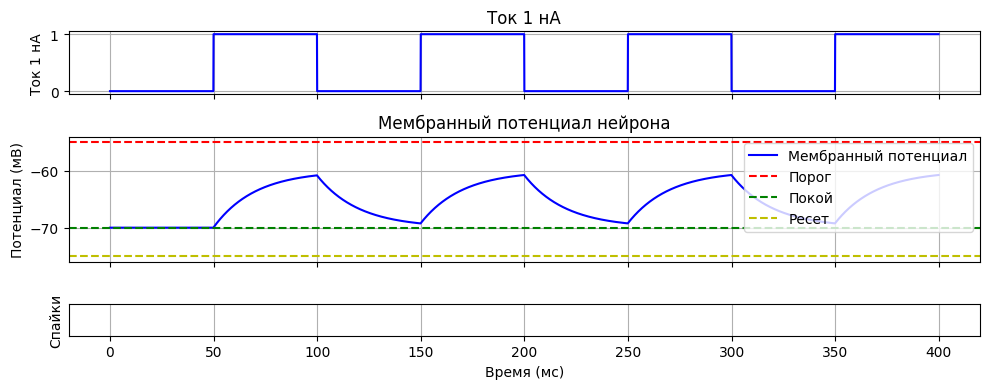

Количество спайков: 0, частота срабатывания  0.00 спайков/период,  0.00 спайков/мс


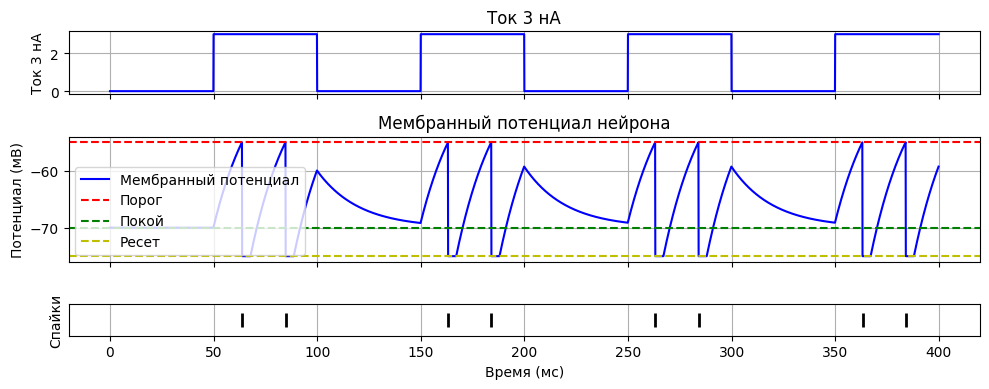

Количество спайков: 8, частота срабатывания  2.00 спайков/период,  0.02 спайков/мс


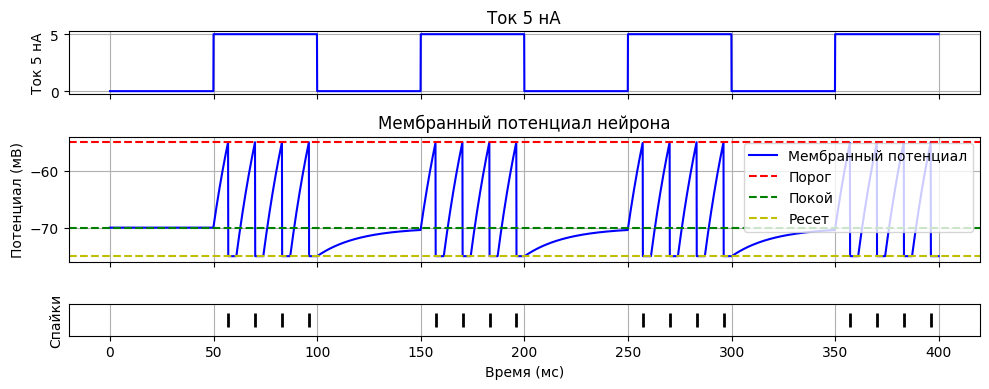

Количество спайков: 16, частота срабатывания  4.00 спайков/период,  0.04 спайков/мс


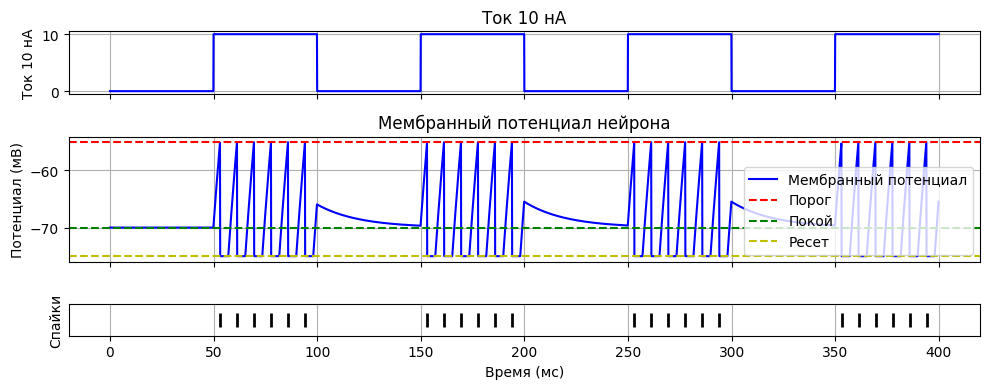

Количество спайков: 24, частота срабатывания  6.00 спайков/период,  0.06 спайков/мс


In [233]:
dt = 0.1
T = 400
t_range = np.arange(0, T, dt)

# for cur in ['sin', 'step', 'triangle']:
for cur in [1, 3, 5, 10]:
    f=4
    I = get_I_from_type(t_range, 'step', A=cur, f=f)

    neu = LIFNeuron()

    for i, t in enumerate(t_range):
        neu.step(I[i], dt, t)

    # Визуализация
    # timeplot(t_range, I, f'Ток {cur}', 2)
    plot_neuron_activity(t_range, neu, f'Мембранный потенциал нейрона',
                         top = True, top_label=f'Ток {cur} нА', top_func=I)
    spikes = len(neu.spike_times)
    print(f"Количество спайков: {spikes}, частота срабатывания {spikes / f: .2f} спайков/период, {spikes / T: .2f} спайков/мс")

С увеличением амплитуды входного сигнала увеличивается частота срабатывания нейрона (количество спайков).

График частоты срабатывания от силы тока (на примере 1 периода ступенчатого сигнала, длина воздействия сигнала 50 мс):

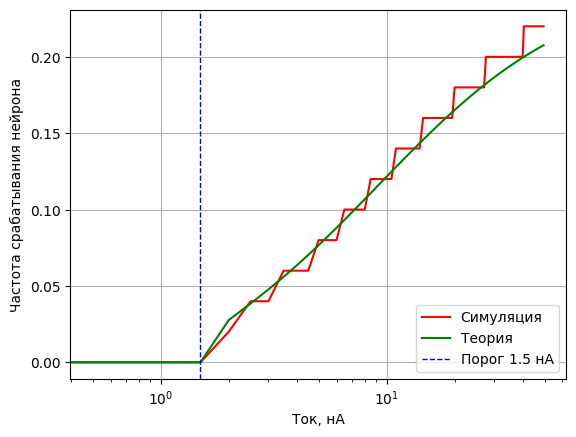

In [234]:
dt = 0.1
T = 50
t_range = np.arange(0, T, dt)
rates = []
currents = np.arange(0, 50, 0.5)
# thr = -1

# for cur in ['sin', 'step', 'triangle']:
for cur in currents:
    # I = get_I_from_type(t_range, 'step', A=cur, f=1)
    I = np.ones_like(t_range)
    I = np.multiply(I, cur)
    neu = LIFNeuron()
    for i, t in enumerate(t_range):
        neu.step(I[i], dt, t)
    spikes = len(neu.spike_times)
    firing_rate = spikes / T
    rates.append(firing_rate)


I_thr   = (LIFNeuron.v_thresh - LIFNeuron.v_rest) / LIFNeuron.r_m
rates_theory = []
for I_th in currents:
    if I_th > I_thr:
        vi = LIFNeuron.v_rest + I_th * LIFNeuron.r_m
        tfr = LIFNeuron.tau_ref + LIFNeuron.tau_m * np.log((vi - LIFNeuron.v_reset) / (vi - LIFNeuron.v_thresh))
        rates_theory.append(1 / tfr)
    else:
        rates_theory.append(0.0)

plt.plot(currents, rates, color='r', label='Симуляция')
plt.plot(currents, rates_theory, color='g', label='Теория')
plt.axvline(x=I_thr, color='b', linestyle='--', linewidth=1, label=f'Порог {I_thr:.1f} нА')
plt.ylabel('Частота срабатывания нейрона')
plt.xlabel('Ток, нА')
plt.xscale('log')
plt.grid(True)
plt.legend()
plt.show()

По данному графику можно видеть, что частота срабатывания нейрона растет логарифмически в зависимости от силы входного тока. При этом при токе менее 1.5 нА спайков не возникает (мембранный потенциал не может стать выше порогового).

Функция для генерации сигналов по количеству входящих нейронов. Модуль сигнала равен A, сам сигнал представляет собой "ступеньку" длиной в n_sec с паузами в pause. n_samples - количество ступенек. В любой момент времени сигнал поступает только на один из входов.

In [235]:
def class_steps(t_range, n_inputs, n_samples, n_sec, pause, A=20):
    I_inj = [np.zeros_like(t_range) for i in range(n_inputs)]
    mlen = min(len(t_range), n_samples)
    mask = np.repeat(np.arange(0, n_inputs), np.ceil(n_samples / n_inputs))[:mlen]

    np.random.shuffle(mask)
    for i, _ in enumerate(t_range):
        sample = i // (n_sec + pause)
        if i % (n_sec + pause) == 0:
            end = min(i + n_sec, len(t_range))
            I_inj[mask[sample]][i:end] = A
    return I_inj, mask

Ниже заданы параметры для симуляции:

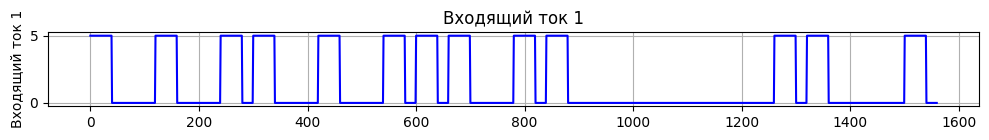

Пиков: 13.0


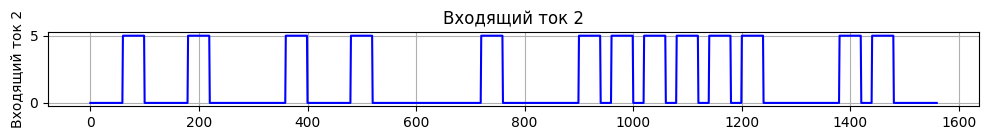

Пиков: 13.0


In [236]:
n_inputs = 2
n_outputs = 2
A_p = 0.01
A_m = 0.001
tau_p = 20
tau_m = 20

n_sec = 40
pause = 20
n_samples = 26
T = (n_sec + pause) * n_samples
dt = 1
t_range = np.arange(0, T, dt)

I_inj, true_labels = class_steps(t_range, n_inputs, n_samples, n_sec, pause, A=5)

for i in range(n_inputs):
    timeplot(t_range, I_inj[i], f'Входящий ток {i + 1}', height=1.5)
    print(f'Пиков: {len(I_inj[i].nonzero()[0]) / n_sec}')

Было сгенерировано два сигнала, активирующихся поочередно. Пусть каждый сигнал представляет собой активацию одного из классов. Сеть имеет такое же количество выходов, которые должны определять, на какой из входов был сигнал.

In [237]:
weights = [
    [20.0, 0.0],
    [0.0, 20.0]
]

print(f'Начальные веса:')
display(weights)

model = SNNNetwork(n_inputs, n_outputs, t_range, I_inj, weights, dt, A_p=A_p, A_m=A_m, tau_p=tau_p, tau_m=tau_m)
model.simulate()

Начальные веса:


[[20.0, 0.0], [0.0, 20.0]]

Входы
Вход 1:


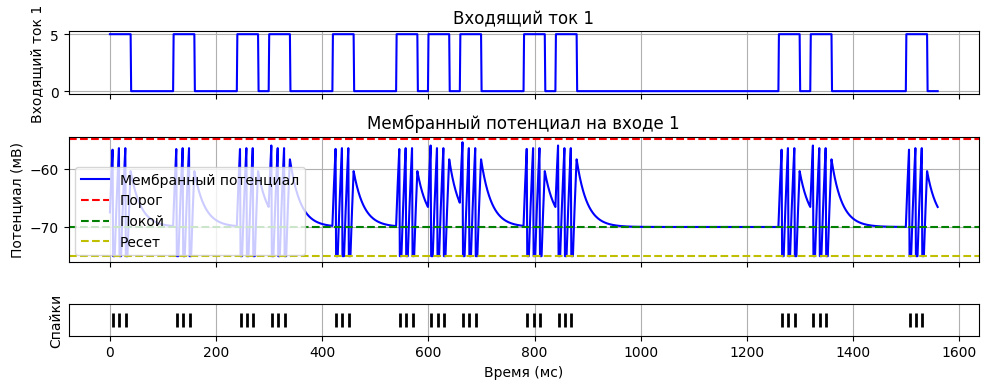

Спайков: 39 (3.0 спайков/образец)
Вход 2:


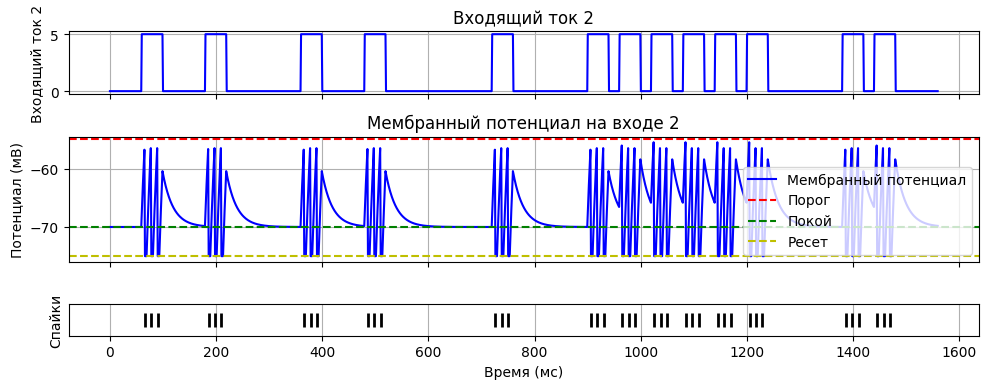

Спайков: 39 (3.0 спайков/образец)
Выходы
Выход 1


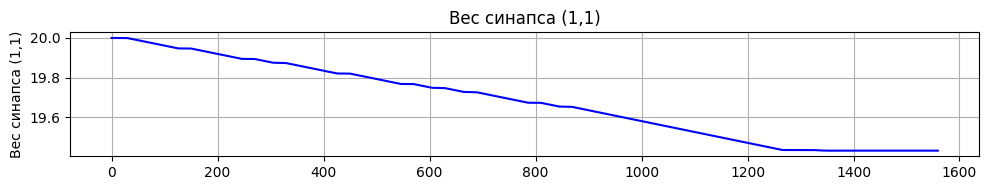

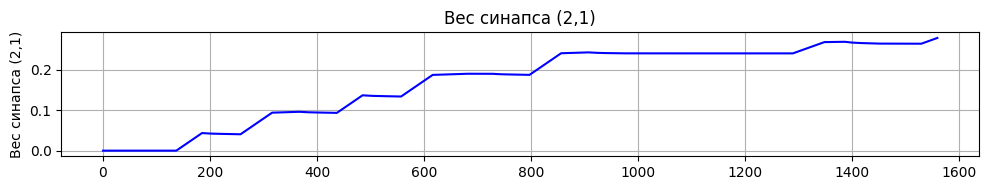

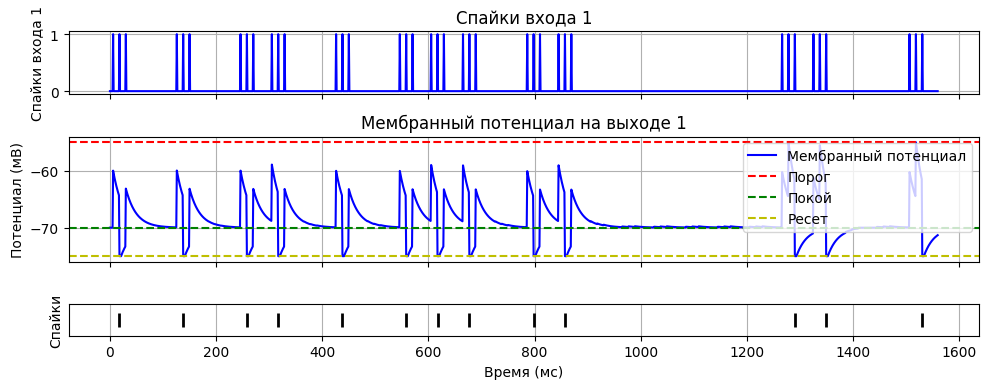

Спайков: 13
Выход 2


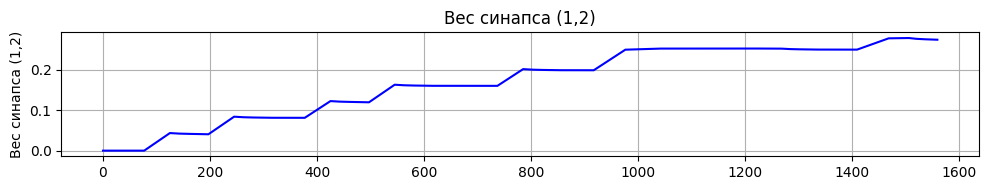

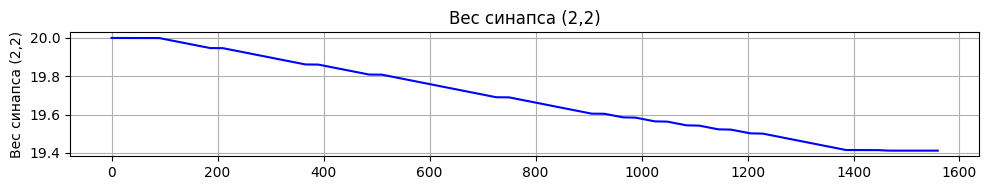

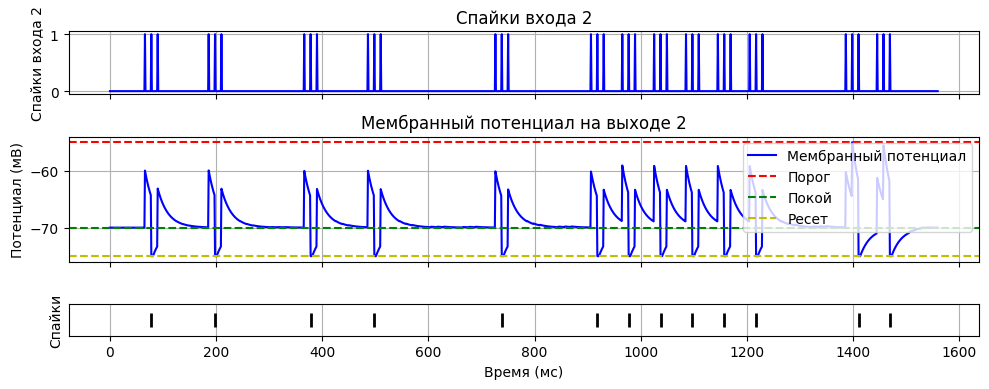

Спайков: 13


In [238]:
print('Входы')
for i, input in enumerate(model.inputs):
    print(f'Вход {i + 1}:')
    plot_neuron_activity(
        model.t_range, input, f'Мембранный потенциал на входе {i + 1}',
        top=True, top_label=f'Входящий ток {i + 1}', top_func=I_inj[i]
        )
    print(f'Спайков: {len(input.spike_times)} ({len(input.spike_times) / (n_samples // n_inputs)} спайков/образец)')
print('Выходы')
for j, output in enumerate(model.outputs):
    print(f'Выход {j + 1}')
    for i in range(n_inputs):
        timeplot(model.t_range, model.weight_history[i][j], height=2, label=f'Вес синапса ({i + 1},{j + 1})')
    plot_neuron_activity(
        model.t_range, output, f'Мембранный потенциал на выходе {j + 1}',
        top=True, top_label=f'Спайки входа {j + 1}', top_func=[1.0 if t in model.inputs[j].spike_times else 0.0 for i, t in enumerate(t_range)]
        )
    print(f'Спайков: {len(output.spike_times)}')

Спайки выходных сигналов однозначно соответствуют пикам входящего тока.

Получение предсказанного значения класса (то есть какой из входов был активен, по мнению выходного нейрона):

In [239]:
def get_pred(model: SNNNetwork, n_samples, n_sec, pause):
    pred_labels = np.zeros(n_samples, dtype=int)

    for sample in range(n_samples):
        t_start = sample * (n_sec + pause)
        t_end = t_start + n_sec

        spike_counts = []
        for j, output in enumerate(model.outputs):
            spike_times = np.array(output.spike_times)
            count = np.sum((spike_times >= t_start) & (spike_times < t_end))
            spike_counts.append(count)
        # print('SP', spike_counts)
        if np.any(spike_counts):
            pred_labels[sample] = np.argmax(spike_counts)
        else:
            pred_labels[sample] = -1
    return pred_labels

In [240]:
def acc(tp, tn, fp, fn):
    if tp + tn + fp + fn > 0.0:
        return  (tp + tn) / (tp + tn + fp + fn)
    return 0

def prec(tp, fp):
    if tp +  fp > 0.0:
        return (tp) / (tp + fp)
    return 0

def rec(tp, fn):
    if tp + fn > 0.0:
        return (tp) / (tp + fn)
    return 0

def f1(prec, rec):
    if prec + rec > 0.0:
        return  2 * prec * rec / (prec + rec)
    return 0

Перемаркировка полученных классов, если их порядок был перепутан:

In [241]:
def remark_matrix(confusion, model: SNNNetwork):
    mat = np.array(confusion)
    n_classes = model.n_outputs
    submat = mat[1:, 1:]

    row_ind, col_ind = linear_sum_assignment(-submat)

    perm = np.zeros(n_classes, dtype=int)

    for i, j in enumerate(col_ind):
        perm[j] = i

    new_mat = np.zeros_like(mat)
    new_mat[0, :] = mat[0, :]
    new_mat[:, 0] = mat[:, 0]

    for true_idx in range(n_classes):
        new_row = true_idx + 1
        old_row = perm[true_idx] + 1
        for true_col in range(n_classes):
            new_col = true_col + 1
            new_mat[new_row, new_col] = mat[old_row, new_col]

    old_outputs = model.outputs.copy()
    old_weights = [w.copy() for w in model.weights]
    old_weight_history = [wh.copy() for wh in model.weight_history]

    for true_idx in range(n_classes):
        new_row = true_idx + 1
        old_row = perm[true_idx] + 1
        model.outputs[new_row - 1] = old_outputs[old_row - 1]
        for i in range(model.n_inputs):
            model.weights[i][new_row - 1] = old_weights[i][old_row - 1]
            model.weight_history[i][new_row - 1] = old_weight_history[i][old_row - 1]
    return new_mat

Функция для получения метрик классификации:

In [242]:
def snn_metrics(y_true, model: SNNNetwork, n_samples, n_sec, pause, verb=False):
    pred_labels = get_pred(model, n_samples, n_sec, pause)

    n_classes = model.n_outputs

    results = {
        'accuracy_micro': 0,
        'accuracy_macro': 0,
        'precision_micro': 0,
        'precision_macro': 0,
        'recall_micro': 0,
        'recall_macro': 0,
        'f1-score_micro': 0,
        'f1-score_macro': 0,
        'misses': 0,
        'confusion': np.zeros((n_classes + 1, n_classes + 1), int)
    }

    # cont_mat = [   
    #     #-1 0  1  y_true
    #     [0, 0, 0],  # -1    y_pred
    #     [0, 0, 0],  # 0
    #     [0, 0, 0]   # 1
    # ]

    for sample in range(n_samples):
        results['confusion'][pred_labels[sample] + 1][y_true[sample] + 1] += 1

    results['confusion'] = remark_matrix(results['confusion'], model)

    tp = np.zeros(n_classes, int)
    tn = np.zeros(n_classes, int)
    fp = np.zeros(n_classes, int)
    fn = np.zeros(n_classes, int)
    
    results['misses'] = sum(results['confusion'][0])

    for i in range(n_classes):
        tp[i] = results['confusion'][i + 1][i + 1]
        fn[i] = np.sum(results['confusion'][:, i + 1]) - tp[i]
        fp[i] = np.sum(results['confusion'][i + 1, :]) - tp[i]
        tn[i] = n_samples - tp[i] - fn[i] - fp[i]

    accuracy = []
    precision = []
    recall = []
    f1_score = []

    # Микро-метрики (усреднение по всем предсказаниям)
    big_tp = np.sum(tp)
    not_missed = n_samples - results['misses']

    results['accuracy_micro'] = big_tp / n_samples if n_samples > 0 else 0.0
    results['precision_micro'] = big_tp / not_missed if not_missed > 0 else 0.0

    for k in range(n_classes):
        accuracy.append(acc(tp[k], tn[k], fp[k], fn[k]))
        precision.append(prec(tp[k], fp[k]))
        recall.append(rec(tp[k], fn[k]))
        f1_score.append(f1(precision[k], recall[k]))

    results['recall_micro'] = big_tp / n_samples  # каждый пример имеет истинный класс
    results['f1-score_micro'] = f1(results['precision_micro'], results['recall_micro'])

    results['accuracy_macro'] = np.mean(accuracy)
    results['precision_macro'] = np.mean(precision)
    results['recall_macro'] = np.mean(recall)
    results['f1-score_macro'] = np.mean(f1_score)
    if verb:
        print(y_true)
        print(pred_labels)
    return results

In [243]:
# print(f"Точность: {spike_accuracy(true_labels, model, n_samples, n_sec, pause):.4f}")

res = snn_metrics(true_labels, model, n_samples, n_sec, pause)
print(f'Accuracy: {res['accuracy_micro']:.4f}')
print(f'Precision: {res['precision_micro']:.4f}')
print(f'Recall: {res['recall_micro']:.4f}')
print(f'f1-score: {res['f1-score_micro']:.4f}')
print(f'Пропущенных меток: {res['misses']}')
display(res['confusion'])

Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
f1-score: 1.0000
Пропущенных меток: 0


array([[ 0,  0,  0],
       [ 0, 13,  0],
       [ 0,  0, 13]])

Сеть выше с вручную заданными весами выдала точность 100%.

Параметры для тестирования сетей с равномерно и нормально заданными весами:

In [244]:
# для нижних (тесты распределений)
n_inputs = 2
n_outputs = 2
A_p = 0.2
A_m = 0.01
tau_p = 20
tau_m = 20

n_sec = 60
pause = 40
n_samples = 20
T = (n_sec + pause) * n_samples
dt = 1

t_range = np.arange(0, T, dt)

Для изучения влияния распределения весов на итоговую точность модели было решено провести обучение нескольких моделей в течение нескольких эпох и вывести среднюю достигнутую точность.

Обучение 10 моделей с равномерно распределенными весами в течение 15 эпох на заданном сигнале (равномерное распределение весов от 0 до А=40):

In [245]:
I_inj, true_labels = class_steps(t_range, n_inputs, n_samples, n_sec, pause, A=10)
tries = 10
epochs = 15
accuracy_uni = []
wh_uni = []
for t in range(tries):
    weights = SNNNetwork.init_weights(n_inputs, n_outputs, set=False, normal=False, A=40)
    accs = []
    wh = []
    for ep in range(epochs):
        model = SNNNetwork(n_inputs, n_outputs, t_range, I_inj, weights, dt, A_p=A_p, A_m=A_m, tau_p=tau_p, tau_m=tau_m)
        model.simulate()

        res = snn_metrics(true_labels, model, n_samples, n_sec, pause)
        accuracy = res['accuracy_micro']

        # if ep == 0 or (ep + 1) % (epochs // 10) == 0:
            # print(f'Эпоха {ep + 1}/{epochs}, точность (микро): {accuracy:.4f}, веса (средний {np.mean(model.weights):.4f})')
        accs.append(accuracy)
        wh.append(model.weight_history)
    print(f'Запуск {t + 1}/{tries}, финальная точность (микро): {accuracy:.4f}, веса (средний {np.mean(model.weights):.4f})')
    accuracy_uni.append(accs)
    wh_uni.append(wh)

Запуск 1/10, финальная точность (микро): 0.5000, веса (средний 47.3848)
Запуск 2/10, финальная точность (микро): 0.4000, веса (средний 9.4925)
Запуск 3/10, финальная точность (микро): 0.5000, веса (средний 17.3860)
Запуск 4/10, финальная точность (микро): 0.5000, веса (средний 19.8928)
Запуск 5/10, финальная точность (микро): 0.5000, веса (средний 45.4411)
Запуск 6/10, финальная точность (микро): 0.5000, веса (средний 32.7019)
Запуск 7/10, финальная точность (микро): 0.0000, веса (средний 8.1946)
Запуск 8/10, финальная точность (микро): 0.5000, веса (средний 15.9670)
Запуск 9/10, финальная точность (микро): 0.5000, веса (средний 16.9771)
Запуск 10/10, финальная точность (микро): 0.5000, веса (средний 24.9309)


В целом точность моделей после 15 эпох падала до случайного угадывания, а у 1 модели веса сильно затухают, что приводит к отсутствию спайков на выходных нейронах (точность 0%, так как ни один класс не был определен).

Обучение 10 моделей в течение 15 эпох для моделей с нормальным распределением весов ($ \mu =20 $, $ \sigma = 11.5 $, приблизительно те же моменты, что у равномерного):

In [246]:
I_inj, true_labels = class_steps(t_range, n_inputs, n_samples, n_sec, pause, A=10)
tries = 10
epochs = 15
accuracy_norm = []
wh_norm = []
for t in range(tries):
    # weights = SNNNetwork.init_weights(n_inputs, n_outputs, set=False, normal=True, mu=20, sigma=11.5)
    weights = SNNNetwork.init_weights(n_inputs, n_outputs, set=False, normal=True, mu=20, sigma=11.5)
    accs = []
    wh = []
    for ep in range(epochs):
        model = SNNNetwork(n_inputs, n_outputs, t_range, I_inj, weights, dt, A_p=A_p, A_m=A_m, tau_p=tau_p, tau_m=tau_m)
        model.simulate()

        res = snn_metrics(true_labels, model, n_samples, n_sec, pause)
        accuracy = res['accuracy_micro']

        # if ep == 0 or (ep + 1) % (epochs // 10) == 0:
            # print(f'Эпоха {ep + 1}/{epochs}, точность (микро): {accuracy:.4f}, веса (средний {np.mean(model.weights):.4f})')
        accs.append(accuracy)
        wh.append(model.weight_history)
    print(f'Запуск {t + 1}/{tries}, финальная точность (микро): {accuracy:.4f}, веса (средний {np.mean(model.weights):.4f})')
    accuracy_norm.append(accs)
    wh_norm.append(wh)

Запуск 1/10, финальная точность (микро): 1.0000, веса (средний 30.7474)
Запуск 2/10, финальная точность (микро): 0.5000, веса (средний 16.7752)
Запуск 3/10, финальная точность (микро): 0.0000, веса (средний 10.2500)
Запуск 4/10, финальная точность (микро): 0.5000, веса (средний 10.8938)
Запуск 5/10, финальная точность (микро): 0.5000, веса (средний 23.7796)
Запуск 6/10, финальная точность (микро): 1.0000, веса (средний 51.0446)
Запуск 7/10, финальная точность (микро): 0.5000, веса (средний 14.3872)
Запуск 8/10, финальная точность (микро): 0.4000, веса (средний 10.4936)
Запуск 9/10, финальная точность (микро): 0.5000, веса (средний 10.2858)
Запуск 10/10, финальная точность (микро): 0.0000, веса (средний 9.5667)


В случае нормального распределения точность после 15 эпох обучения немного лучше, но также вырождалась в случайное угадывание. 2 модели потеряли спайковую активность, а 2 обучились определять классы со 100% точностью.

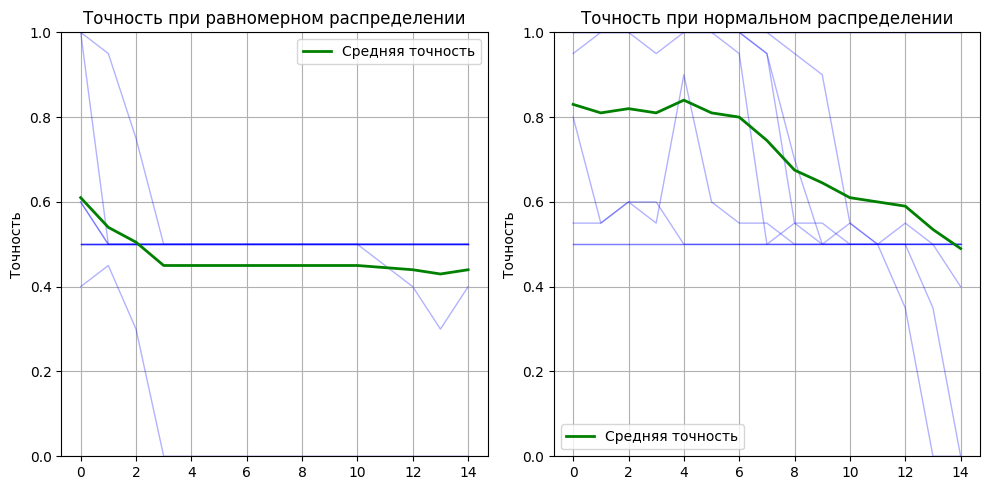

In [247]:
fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(10, 5))

epran = np.arange(0, epochs)
part = len(t_range)
epran_long = np.arange(0, part * epochs)

accuracy_mean_uni = np.mean(accuracy_uni, axis=0)
accuracy_mean_norm = np.mean(accuracy_norm, axis=0)

for t in range(tries):
    ax1.plot(epran, accuracy_uni[t], 'b', alpha=0.3, linewidth=1)
    ax2.plot(epran, accuracy_norm[t], 'b', alpha=0.3, linewidth=1)
ax1.plot(epran, accuracy_mean_uni, 'g', linewidth=2, label='Средняя точность')
ax2.plot(epran, accuracy_mean_norm, 'g', linewidth=2, label='Средняя точность')
ax1.set_title('Точность при равномерном распределении')
ax2.set_title('Точность при нормальном распределении')
ax1.set_ylabel('Точность')
ax2.set_ylabel('Точность')
ax1.set_ylim(bottom=0, top=1)
ax2.set_ylim(bottom=0, top=1)
ax1.legend()
ax2.legend()
ax1.grid(True)
ax2.grid(True)
plt.tight_layout()
plt.show()

На данном графике можно видеть, что в среднем точность моделей с нормальным распределением весов выше, чем у моделей с равномерным распределением. У моделей с равномерным распределением точность неоднократно падала в 0 (веса опускались настолько, что спайковая активность на выходе прекращалась). Модели с нормальным распределением же почти не опускают точность ниже 50% (только на последних эпохах).

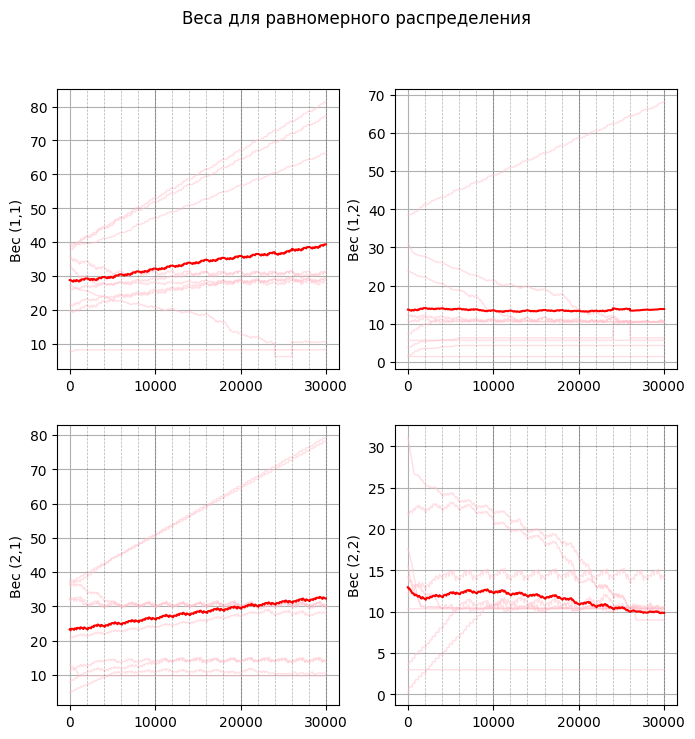

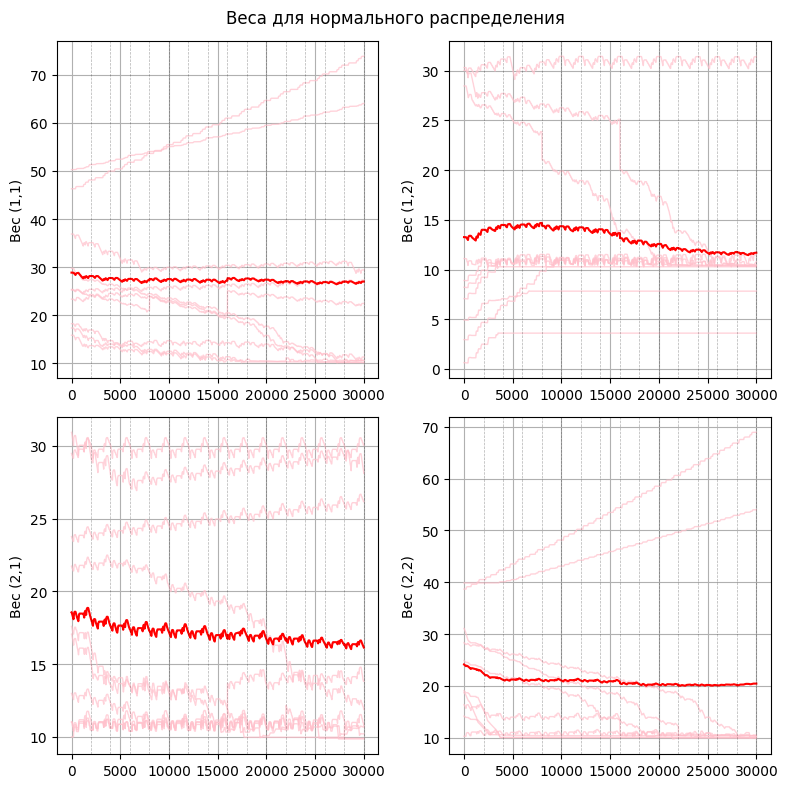

In [248]:
wh_mean_uni = np.concat(np.mean(wh_uni, axis=0), axis=2)
wh_mean_norm = np.concat(np.mean(wh_norm, axis=0), axis=2)
wh_per_e_uni = [np.concat(t, axis=2) for t in wh_uni]
wh_per_e_norm = [np.concat(t, axis=2) for t in wh_norm]

fig, axs = plt.subplots(n_inputs, n_outputs, figsize=(8, 8))
plt.suptitle('Веса для равномерного распределения')
for i in range(n_inputs):
    for j in range(n_outputs):
        for t in range(tries):
            axs[i][j].plot(epran_long, wh_per_e_uni[t][i][j], 'pink', alpha=0.5, linewidth=1)
        axs[i][j].plot(epran_long, wh_mean_uni[i][j], 'r', label='Средний вес')
        for ep in epran:
            axs[i][j].axvline(x=(ep + 1) * part, color='black', linestyle='--', linewidth=0.5, alpha=0.3)
        # axs[i][j].set_ybound(0, np.max(whep[i][j]) * 1.1)
        axs[i][j].set_ylabel(f'Вес ({i + 1},{j + 1})')
        axs[i][j].grid(True)

fig, axs = plt.subplots(n_inputs, n_outputs, figsize=(8, 8))
plt.suptitle('Веса для нормального распределения')
for i in range(n_inputs):
    for j in range(n_outputs):
        for t in range(tries):
            axs[i][j].plot(epran_long, wh_per_e_norm[t][i][j], 'pink', alpha=0.7, linewidth=1)
        axs[i][j].plot(epran_long, wh_mean_norm[i][j], 'r', label='Средний вес')
        for ep in epran:
            axs[i][j].axvline(x=(ep + 1) * part, color='black', linestyle='--', linewidth=0.5, alpha=0.3)
        # axs[i][j].set_ybound(0, np.max(whep[i][j]) * 1.1)
        axs[i][j].set_ylabel(f'Вес ({i + 1},{j + 1})')
        axs[i][j].grid(True)

plt.tight_layout()
plt.show()

По истории весов моделей для равномерного распределения можно видеть, что происходил бесконтрольный рост весов. В то же время в большинстве случаев веса либо росли, либо почти не изменялись и выходили на плато. Преобладает потенциация - рост весов.

Нормальные модели также имеют случаи взрыва весов и выхода на плато, но меньше. В целом у этих моделей преобладала депрессия.

## Вывод

В ходе выполнения работы была реализована модель LIF-нейрона и исследована его реакция на различные уровни входного тока. Установлено, что частота генерации спайков подчиняется теоретической зависимости, возрастая с увеличением тока и ограничиваясь рефрактерным периодом. Созданная двухслойная спайковая сеть продемонстрировала способность к распространению активности: входные нейроны преобразовывали постоянный ток в спайковые последовательности, которые через пластичные синапсы воздействовали на выходные нейроны.

Реализация STDP-правила позволила наблюдать изменение синаптических весов в зависимости от временных корреляций между спайками. Обучение сети на задаче различения двух паттернов (активация разных входов) показало, что при сбалансированной инициализации весов (нормальное распределение) сеть способна достичь высокой точности классификации (до 100%). В случае равномерного распределения с большим разбросом наблюдалось доминирование одного выходного нейрона, что приводило к снижению точности до случайного уровня.

Анализ динамики весов и матрицы ошибок подтвердил, что успешность обучения сильно зависит от начальных условий и параметров STDP. Полученные результаты демонстрируют принципиальную возможность обучения спайковых сетей на простых временных паттернах, однако для повышения стабильности и надёжности требуются дополнительные механизмы.